
## Module 8: Model Evaluation — Mini Project
Goal: Measure model performance correctly using a comprehensive suite of metrics and diagnostic tools.

This mini project covers:
1. Regression Metrics (MSE, MAE, R²)
2. Classification Metrics (Accuracy, Precision, Recall, F1)
3. Confusion Matrix
4. Classification Report
5. ROC Curve
6. Precision-Recall Curve
7. Learning Curve
8. Validation Curve
9. Error Analysis (residuals, misclassifications)

We'll use two datasets:
- Diabetes (regression) for regression metrics.
- Breast Cancer (classification) for classification metrics.
We'll apply a Random Forest model and evaluate thoroughly.



In [1]:

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_diabetes, load_breast_cancer
from sklearn.model_selection import train_test_split, learning_curve, validation_curve, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, mean_absolute_error, r2_score,
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, ConfusionMatrixDisplay, classification_report,
    roc_curve, roc_auc_score, precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import StandardScaler


## 1. Load datasets


In [2]:
print("=" * 60)
print("STEP 1: Load Datasets")
print("=" * 60)

# Regression dataset: Diabetes
diabetes = load_diabetes()
X_reg = diabetes.data
y_reg = diabetes.target
print(f"Diabetes dataset: {X_reg.shape[0]} samples, {X_reg.shape[1]} features (regression)")

# Classification dataset: Breast Cancer
cancer = load_breast_cancer()
X_clf = cancer.data
y_clf = cancer.target
print(f"Breast Cancer dataset: {X_clf.shape[0]} samples, {X_clf.shape[1]} features (binary classification)")


STEP 1: Load Datasets
Diabetes dataset: 442 samples, 10 features (regression)
Breast Cancer dataset: 569 samples, 30 features (binary classification)


## 2. Split data


In [3]:
print("\n" + "=" * 60)
print("STEP 2: Train/Test Splits")
print("=" * 60)

X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print("Regression split: train size", X_train_reg.shape[0], "test size", X_test_reg.shape[0])
print("Classification split: train size", X_train_clf.shape[0], "test size", X_test_clf.shape[0])



STEP 2: Train/Test Splits
Regression split: train size 353 test size 89
Classification split: train size 455 test size 114


## 3. Train models


In [4]:
print("\n" + "=" * 60)
print("STEP 3: Train Random Forest Models")
print("=" * 60)

# Regression model
regressor = RandomForestRegressor(n_estimators=100, random_state=42)
regressor.fit(X_train_reg, y_train_reg)
y_pred_reg = regressor.predict(X_test_reg)

# Classification model
classifier = RandomForestClassifier(n_estimators=100, random_state=42)
classifier.fit(X_train_clf, y_train_clf)
y_pred_clf = classifier.predict(X_test_clf)
y_proba_clf = classifier.predict_proba(X_test_clf)[:, 1]  # for ROC/PR

print("Models trained successfully.")



STEP 3: Train Random Forest Models
Models trained successfully.


## 4. Regression Metrics



STEP 4: Regression Metrics
Mean Squared Error (MSE): 2952.0106
Mean Absolute Error (MAE): 44.0530
R² Score: 0.4428


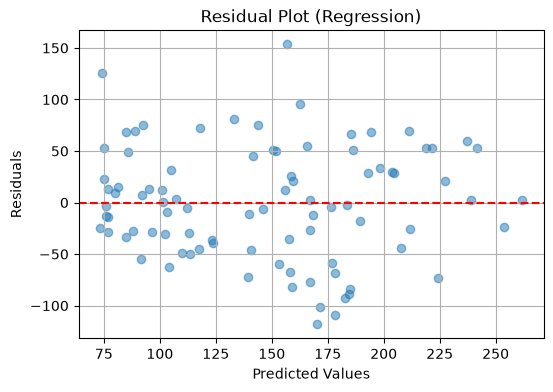

In [5]:
print("\n" + "=" * 60)
print("STEP 4: Regression Metrics")
print("=" * 60)

mse = mean_squared_error(y_test_reg, y_pred_reg)
mae = mean_absolute_error(y_test_reg, y_pred_reg)
r2 = r2_score(y_test_reg, y_pred_reg)

print(f"Mean Squared Error (MSE): {mse:.4f}")
print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"R² Score: {r2:.4f}")

# Residual plot for error analysis
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(6,4))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Values')
plt.ylabel('Residuals')
plt.title('Residual Plot (Regression)')
plt.grid(True)
plt.show()


## 5. Classification Metrics


In [6]:
print("\n" + "=" * 60)
print("STEP 5: Classification Metrics")
print("=" * 60)

accuracy = accuracy_score(y_test_clf, y_pred_clf)
precision = precision_score(y_test_clf, y_pred_clf)
recall = recall_score(y_test_clf, y_pred_clf)
f1 = f1_score(y_test_clf, y_pred_clf)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1 Score:  {f1:.4f}")



STEP 5: Classification Metrics
Accuracy:  0.9649
Precision: 0.9589
Recall:    0.9859
F1 Score:  0.9722


## 6. Confusion Matrix



STEP 6: Confusion Matrix
Confusion Matrix:
[[40  3]
 [ 1 70]]


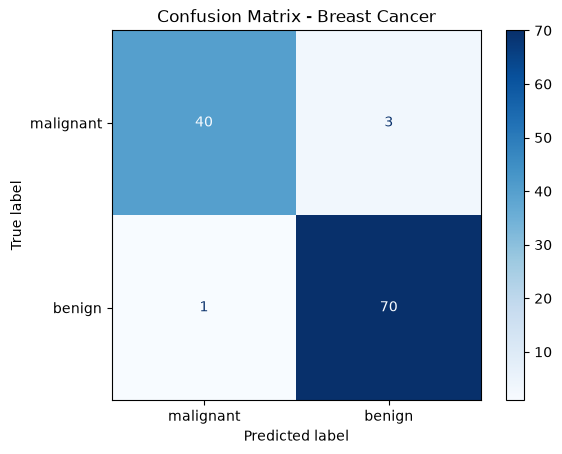

In [7]:
print("\n" + "=" * 60)
print("STEP 6: Confusion Matrix")
print("=" * 60)

cm = confusion_matrix(y_test_clf, y_pred_clf)
print("Confusion Matrix:")
print(cm)

# Visualise
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=cancer.target_names)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Breast Cancer')
plt.show()


## 7. Classification Report


In [8]:
print("\n" + "=" * 60)
print("STEP 7: Classification Report")
print("=" * 60)

print(classification_report(y_test_clf, y_pred_clf, target_names=cancer.target_names))



STEP 7: Classification Report
              precision    recall  f1-score   support

   malignant       0.98      0.93      0.95        43
      benign       0.96      0.99      0.97        71

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114



## 8. ROC Curve



STEP 8: ROC Curve
AUC (Area Under ROC Curve): 0.9953


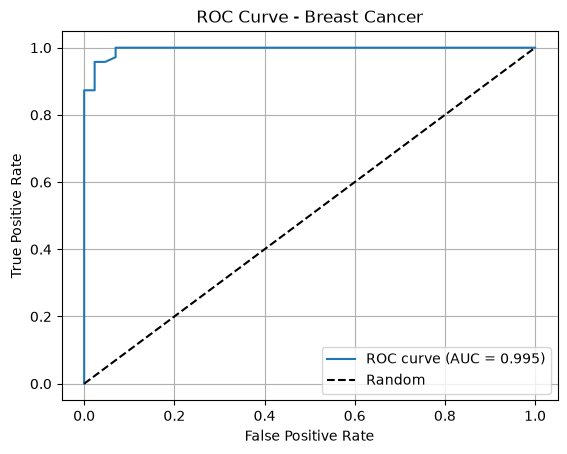

In [9]:
print("\n" + "=" * 60)
print("STEP 8: ROC Curve")
print("=" * 60)

fpr, tpr, thresholds = roc_curve(y_test_clf, y_proba_clf)
auc = roc_auc_score(y_test_clf, y_proba_clf)
print(f"AUC (Area Under ROC Curve): {auc:.4f}")

plt.figure()
plt.plot(fpr, tpr, label=f'ROC curve (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Breast Cancer')
plt.legend()
plt.grid(True)
plt.show()


## 9. Precision-Recall Curve



STEP 9: Precision-Recall Curve
Average Precision (AP): 0.9970


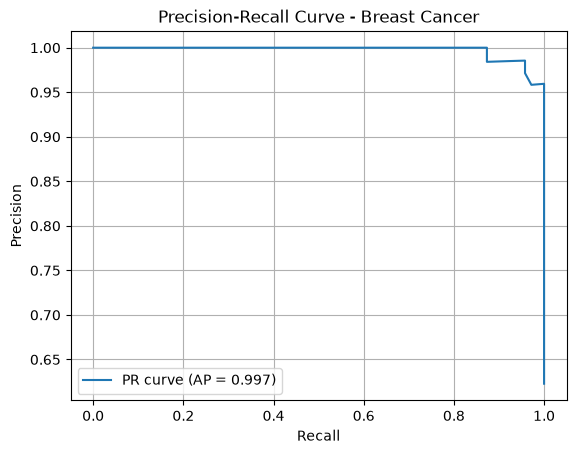

In [10]:
print("\n" + "=" * 60)
print("STEP 9: Precision-Recall Curve")
print("=" * 60)

precision_pr, recall_pr, _ = precision_recall_curve(y_test_clf, y_proba_clf)
ap = average_precision_score(y_test_clf, y_proba_clf)
print(f"Average Precision (AP): {ap:.4f}")

plt.figure()
plt.plot(recall_pr, precision_pr, label=f'PR curve (AP = {ap:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve - Breast Cancer')
plt.legend()
plt.grid(True)
plt.show()


## 10. Learning Curve



STEP 10: Learning Curve (for Classification Model)


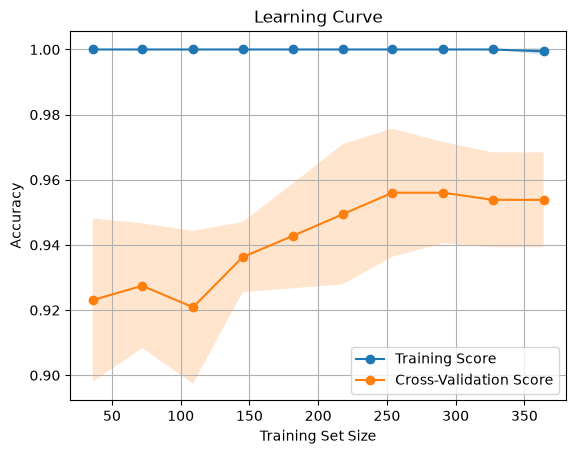

In [11]:
print("\n" + "=" * 60)
print("STEP 10: Learning Curve (for Classification Model)")
print("=" * 60)

train_sizes, train_scores, test_scores = learning_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_train_clf, y_train_clf, cv=5,
    train_sizes=np.linspace(0.1, 1.0, 10),
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()
plt.plot(train_sizes, train_mean, label='Training Score', marker='o')
plt.fill_between(train_sizes, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(train_sizes, test_mean, label='Cross-Validation Score', marker='o')
plt.fill_between(train_sizes, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.xlabel('Training Set Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.grid(True)
plt.show()


## 11. Validation Curve



STEP 11: Validation Curve (Tuning max_depth)


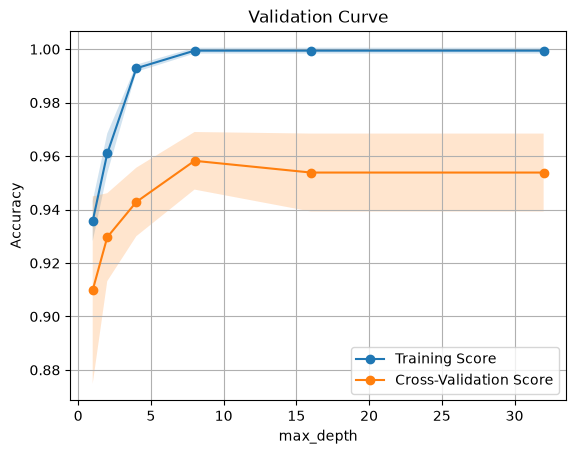

In [12]:
print("\n" + "=" * 60)
print("STEP 11: Validation Curve (Tuning max_depth)")
print("=" * 60)

param_range = [1, 2, 4, 8, 16, 32]
train_scores, test_scores = validation_curve(
    RandomForestClassifier(n_estimators=50, random_state=42),
    X_train_clf, y_train_clf,
    param_name='max_depth',
    param_range=param_range,
    cv=5,
    scoring='accuracy'
)

train_mean = np.mean(train_scores, axis=1)
train_std = np.std(train_scores, axis=1)
test_mean = np.mean(test_scores, axis=1)
test_std = np.std(test_scores, axis=1)

plt.figure()
plt.plot(param_range, train_mean, label='Training Score', marker='o')
plt.fill_between(param_range, train_mean - train_std, train_mean + train_std, alpha=0.2)
plt.plot(param_range, test_mean, label='Cross-Validation Score', marker='o')
plt.fill_between(param_range, test_mean - test_std, test_mean + test_std, alpha=0.2)
plt.xlabel('max_depth')
plt.ylabel('Accuracy')
plt.title('Validation Curve')
plt.legend()
plt.grid(True)
plt.show()


## 12. Error Analysis



STEP 12: Error Analysis (Classification)
Number of misclassified samples: 4
Misclassification rate: 0.0351

Top 5 most important features:
                 feature  importance
23            worst area    0.153892
27  worst concave points    0.144663
7    mean concave points    0.106210
20          worst radius    0.077987
6         mean concavity    0.068001


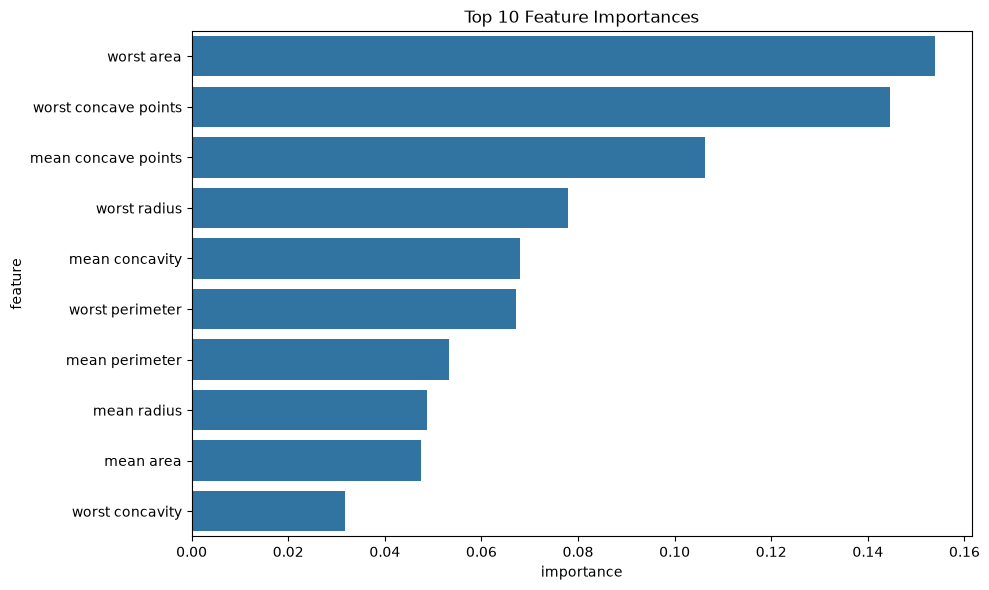

In [13]:
print("\n" + "=" * 60)
print("STEP 12: Error Analysis (Classification)")
print("=" * 60)

# Identify misclassified samples
misclassified = y_test_clf != y_pred_clf
print(f"Number of misclassified samples: {misclassified.sum()}")
print(f"Misclassification rate: {misclassified.sum() / len(y_test_clf):.4f}")

# Show feature importance for insights
importances = classifier.feature_importances_
feature_names = cancer.feature_names
importance_df = pd.DataFrame({'feature': feature_names, 'importance': importances}).sort_values('importance', ascending=False)
print("\nTop 5 most important features:")
print(importance_df.head(5))

# Plot feature importances
plt.figure(figsize=(10,6))
sns.barplot(data=importance_df.head(10), x='importance', y='feature')
plt.title('Top 10 Feature Importances')
plt.tight_layout()
plt.show()


## 13. Summary


In [14]:
print("\n" + "=" * 60)
print("📊 Mini Project Complete!")
print("=" * 60)
print("Evaluation techniques covered:")
print(" ✅ Regression Metrics: MSE, MAE, R²")
print(" ✅ Classification Metrics: Accuracy, Precision, Recall, F1")
print(" ✅ Confusion Matrix")
print(" ✅ Classification Report")
print(" ✅ ROC Curve & AUC")
print(" ✅ Precision-Recall Curve & AP")
print(" ✅ Learning Curve")
print(" ✅ Validation Curve")
print(" ✅ Error Analysis (residuals, misclassifications, feature importance)")


📊 Mini Project Complete!
Evaluation techniques covered:
 ✅ Regression Metrics: MSE, MAE, R²
 ✅ Classification Metrics: Accuracy, Precision, Recall, F1
 ✅ Confusion Matrix
 ✅ Classification Report
 ✅ ROC Curve & AUC
 ✅ Precision-Recall Curve & AP
 ✅ Learning Curve
 ✅ Validation Curve
 ✅ Error Analysis (residuals, misclassifications, feature importance)
